In [14]:
print("neha")

neha


In [15]:
import numpy as np
import pandas as pd

In [16]:
data = pd.read_csv(r"C:\Users\nehas\OneDrive\Desktop\Customer-Churn-Prediction\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [17]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [19]:
data["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

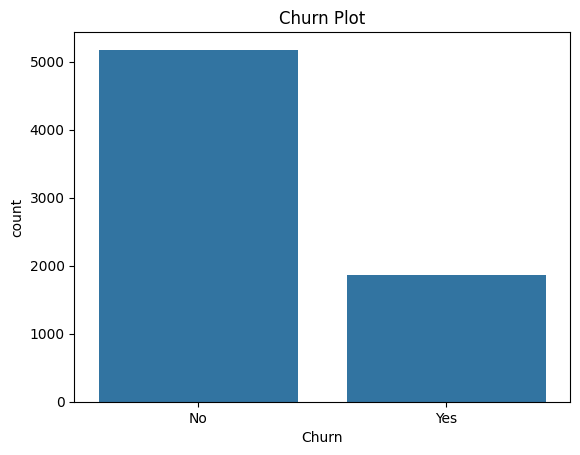

In [21]:
sns.countplot(x = "Churn" , data = data )
plt.title("Churn Plot")
plt.show()

In [22]:
data['tenure_group'] = pd.cut(data['tenure'],
                           bins=[0, 12, 24, 48, 72],
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

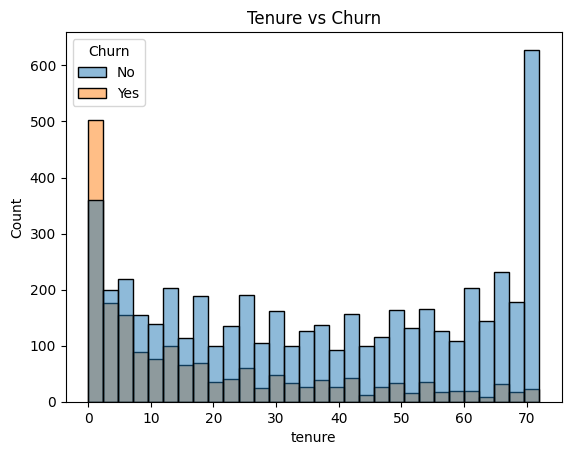

In [23]:
sns.histplot(data=data, x='tenure', hue='Churn', bins=30)
plt.title("Tenure vs Churn")
plt.show()

In [24]:
data['InternetService'].unique()

<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

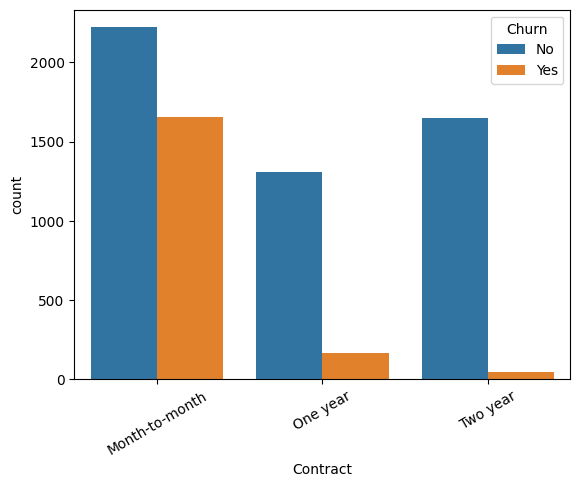

In [25]:
sns.countplot(x='Contract', hue='Churn', data=data)
plt.xticks(rotation=30)
plt.show()

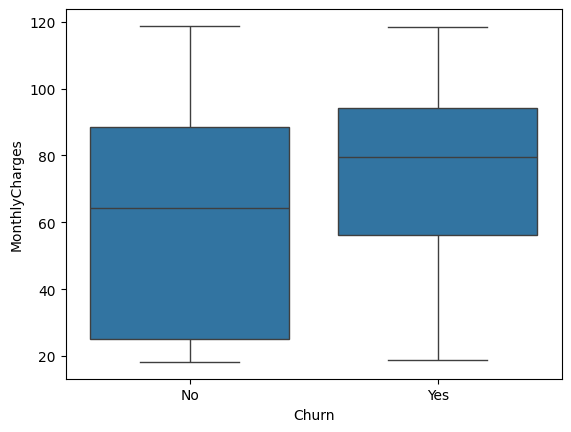

In [26]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.show()

In [27]:
services = ['PhoneService' , 'MultipleLines' , 'InternetService' ,
            'OnlineSecurity' , 'TechSupport' , 'StreamingTV' , 'StreamingMovies',
            'DeviceProtection']
data['total_services'] = data[services].apply(lambda x : (x == 'Yes').sum() , axis = 1)

In [28]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,2-4yr,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4yr,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,1


In [29]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['avg_charge'] = data['TotalCharges'] / (data['tenure']+1)

In [30]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,avg_charge
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1yr,0,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4yr,3,53.985714
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1yr,2,36.050000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4yr,3,40.016304
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1yr,1,50.550000


In [31]:
data.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,total_services,avg_charge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
data = data.drop('customerID' , axis = 1)

In [39]:
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,total_services,avg_charge,gender_Female,gender_Male,Partner_No,Partner_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes,tenure_group_0-1yr,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,0,14.925000,True,False,False,True,...,False,False,True,False,True,False,True,False,False,False
1,0,34,56.95,1889.50,3,53.985714,False,True,True,False,...,False,False,False,True,True,False,False,False,True,False
2,0,2,53.85,108.15,2,36.050000,False,True,True,False,...,False,False,False,True,False,True,True,False,False,False
3,0,45,42.30,1840.75,3,40.016304,False,True,True,False,...,True,False,False,False,True,False,False,False,True,False
4,0,2,70.70,151.65,1,50.550000,True,False,True,False,...,False,False,True,False,False,True,True,False,False,False


In [34]:
data = pd.get_dummies(data)

In [35]:
data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,total_services,avg_charge,gender_Female,gender_Male,Partner_No,Partner_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes,tenure_group_0-1yr,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,0,14.925000,True,False,False,True,...,False,False,True,False,True,False,True,False,False,False
1,0,34,56.95,1889.50,3,53.985714,False,True,True,False,...,False,False,False,True,True,False,False,False,True,False
2,0,2,53.85,108.15,2,36.050000,False,True,True,False,...,False,False,False,True,False,True,True,False,False,False
3,0,45,42.30,1840.75,3,40.016304,False,True,True,False,...,True,False,False,False,True,False,False,False,True,False
4,0,2,70.70,151.65,1,50.550000,True,False,True,False,...,False,False,True,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,7,79.620000,False,True,False,True,...,False,False,False,True,True,False,False,True,False,False
7039,0,72,103.20,7362.90,5,100.861644,True,False,False,True,...,False,True,False,False,True,False,False,False,False,True
7040,0,11,29.60,346.45,1,28.870833,True,False,False,True,...,False,False,True,False,True,False,True,False,False,False
7041,1,4,74.40,306.60,2,61.320000,False,True,False,True,...,False,False,False,True,False,True,True,False,False,False


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X = data.drop(['Churn_Yes' , 'Churn_No' ], axis = 1)
y = data['Churn_Yes']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.3 , random_state=42)

X_train.shape , X_test.shape

((4930, 51), (2113, 51))

In [38]:
data.to_csv("processed_churn.csv" , index = False)